# Modul 7: Unsupervised Learning
**Project-Based Internship VINIX7**

Kelompok 3 (Universitas Sultan Ageng Tirtayasa)

Anggota Kelompok: Ahmad Jumhadi, Azhriler Lintang, Aura Salsa Azzahra

In [ ]:
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

df = pd.read_csv('tokopedia_product_reviews_2025.csv')
display(df.head())

,review_text,review_date,review_id,product_name,product_category,product_variant,product_price,product_url,product_id,rating,sold_count,shop_id,sentiment_label
0,"baru sekali ini terima brg dr belanja online dg packing super rapih dan aman. semula ragu, bagaimana mungkin mmbeli terlur ayam mentah , sec online. tp ternyata packing liar biasa. rapi, aman. Kerem seller",2024-12-22,1134256160,Telur Ayam Kampung Asli - Telur Mengandung Omega 3,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telur-ayam-kampung-asli-telur-mengandung-omega-3-1731491654043338692?extParam=ivf%3Dfalse,4601033481,5,1000000,8672687,positive
1,cocok bgt aku sama telur nya. nga Amis menurutku dan nga neg jadi nya. diterima dengan baik dan aman. terimakasih,2025-02-25,1242584634,Telur Ayam Kampung Asli - Telur Mengandung Omega 3,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telur-ayam-kampung-asli-telur-mengandung-omega-3-1731491654043338692?extParam=ivf%3Dfalse,4601033481,5,1000000,8672687,positive
2,"Telornya sudah sampai di rumah dengan kemasan yang sangat rapi, luar biasa. Terimakasih buat sellernya. Mantaps.",2025-07-15,1573444677,Telur Ayam Kampung Asli - Telur Mengandung Omega 3,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telur-ayam-kampung-asli-telur-mengandung-omega-3-1731491654043338692?extParam=ivf%3Dfalse,4601033481,5,1000000,8672687,positive
3,"Telor sudah diterima dengan baik dan tidak ada yang pecah, terimakasih buat sellernya.",2025-07-20,1581728541,Telur Ayam Kampung Asli - Telur Mengandung Omega 3,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telur-ayam-kampung-asli-telur-mengandung-omega-3-1731491654043338692?extParam=ivf%3Dfalse,4601033481,5,1000000,8672687,positive
4,"Alhamdulillah penjual amanah,Telor nya terbaik,sedap lezat sekali di bikin telor setengah matang.pembelian ke 2...In Syaa Allah menjadi langganan",2023-04-24,881041355,Telur Ayam Kampung Asli - Telur Mengandung Omega 3,Makanan & Minuman,Box Full Design,87000,https://www.tokopedia.com/indofarmproduct/telur-ayam-kampung-asli-telur-mengandung-omega-3-1731491654043338692?extParam=ivf%3Dfalse,4601033481,5,1000000,8672687,positive


Pada tahap awal ini, dataset dimuat menggunakan pandas lalu ditampilkan beberapa baris isinya untuk memastikan bahwa data telah berhasil dimuat dengan benar dan melihat gambaran awal struktur kolom dan isinya.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65543 entries, 0 to 65542
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   review_text       65543 non-null  object
 1   review_date       65543 non-null  object
 2   review_id         65543 non-null  int64 
 3   product_name      65543 non-null  object
 4   product_category  65543 non-null  object
 5   product_variant   26749 non-null  object
 6   product_price     65543 non-null  int64 
 7   product_url       65543 non-null  object
 8   product_id        65543 non-null  int64 
 9   rating            65543 non-null  int64 
 10  sold_count        65543 non-null  int64 
 11  shop_id           65543 non-null  int64 
 12  sentiment_label   65543 non-null  object
dtypes: int64(6), object(7)
memory usage: 6.5+ MB


Selanjutnya, dari hasil df.info(), terlihat bahwa dataset memiliki 65543 baris data dengan total 13 kolom. Sebagian besar data tidak memiliki missing value kecuali kolom product_variant.

In [ ]:
import warnings
warnings.filterwarnings("ignore")
import os
os.environ['PYTHONWARNINGS'] = 'ignore'

Kode ini dilakukan untuk menonaktifkan warning dari python agar output notebook lebih bersih dan tidak terganggu oleh pesan yang sebenarnya tidak terlalu penting.

In [ ]:
from sklearn.preprocessing import StandardScaler

df['review_length'] = df['review_text'].astype(str).str.len()
df['is_positive'] = (df['sentiment_label'] == 'positive').astype(int)
df['product_variant'] = df['product_variant'].fillna('No Variant')

df_agg = df.groupby('product_id').agg(
    avg_price=('product_price', 'mean'),
    total_sold=('sold_count', 'max'),
    positive_pct=('is_positive', 'mean'),
    avg_review_len=('review_length', 'mean')
).reset_index()

scaler = StandardScaler()
features_to_scale = ['avg_price', 'total_sold', 'positive_pct', 'avg_review_len']
scaled_values = scaler.fit_transform(df_agg[features_to_scale])

df_scaled = pd.DataFrame(scaled_values, columns=[f"{col}_scaled" for col in features_to_scale])
df_agg_final = pd.concat([df_agg, df_scaled], axis=1)

display(df_agg_final.head())

,product_id,avg_price,total_sold,positive_pct,avg_review_len,avg_price_scaled,total_sold_scaled,positive_pct_scaled,avg_review_len_scaled
0,4298375,1768000.0,100,1.000000,127.850000,0.161647,-0.081455,0.331992,1.144883
1,12313359,78000.0,3000,1.000000,84.150000,-0.224124,0.124325,0.331992,0.258833
2,21172457,150000.0,2000,1.000000,1076.150000,-0.207689,0.053367,0.331992,20.372378
3,22825312,160000.0,250,0.944444,40.333333,-0.205406,-0.070811,-0.682200,-0.629583
4,22845300,750000.0,100,1.000000,56.529412,-0.070729,-0.081455,0.331992,-0.301195


Selanjutnya, dilakukan preprocessing tambahan. review_length dibuat untuk mengukur panjang ulasan sebagai indikator seberapa detail pelanggan memberikan feedback. Dibuat juga kolom is_positive untuk mengubah label sentimen menjadi bentuk numerik. Selain itu, missing value pada product_variant diisi dengan label “No Variant” agar tidak mengganggu proses pengolahan data.

Setelah itu, dilakukan proses agregasi data dengan groupby berdasarkan product_id. Terdapat beberapa metrik agregasi untuk setiap produk seperti rata-rata harga (avg_price), total penjualan (total_sold), persentase ulasan positif (positive_pct), dan rata-rata panjang ulasan (avg_review_len).

Terakhir, dilakukan scaling menggunakan StandardScaler pada fitur-fitur numerik hasil agregasi agar semua fitur berada dalam skala yang sebanding. Hal ini penting karena tanpa scaling, fitur seperti harga atau jumlah terjual bisa mendominasi hasil clustering. Hasil akhirnya terlihat pada dataframe df_agg_final, yang memiliki fitur asli dan versi terstandarisasi.

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pcs = pca.fit_transform(df_agg_final[['avg_price_scaled', 'total_sold_scaled', 'positive_pct_scaled', 'avg_review_len_scaled']])

df_agg_final['PC1'] = pcs[:, 0]
df_agg_final['PC2'] = pcs[:, 1]

variance_ratio = pca.explained_variance_ratio_
total_variance = variance_ratio.sum()

print("Explained Variance PC1 & PC2:", variance_ratio)
print(f"Total Information Retained: {total_variance:.2%}")

Explained Variance PC1 & PC2: [0.27399461 0.26501967]
Total Information Retained: 53.90%


**Interpretasi 1:** Dari output yang dihasilkan, terlihat bahwa PC1 menjelaskan sekitar 27.4% varians dan PC2 sekitar 26.5%, sehingga total informasi yang berhasil dipertahankan oleh dua komponen ini adalah sekitar 53.9%. Artinya, lebih dari setengah informasi dari data asli masih bisa direpresentasikan hanya dengan dua dimensi. Namun, angka ini juga menunjukkan bahwa masih ada sekitar 46% informasi yang hilang.

Dua komponen utama (PC1 dan PC2) berhasil mempertahankan 53.9% varians. Secara kritis, persentase ini sebenarnya cukup rendah untuk merepresentasikan keseluruhan informasi data secara utuh. Namun, mereduksi ke 2 Dimensi adalah kompromi yang sangat ideal dan perlu dilakukan demi kebutuhan visualisasi interpretatif. Untuk implementasi clustering di tahap production masa depan, idealnya kita menggunakan seluruh fitur atau menambahkan komponen PC hingga mencapai explained variance >70%.

Dari sisi bisnis, ini berarti representasi produk dalam bentuk 2 dimensi sudah cukup untuk memberikan gambaran kasar tentang perbedaan karakteristik antar produk, seperti mana yang cenderung high-performing atau mana yang punya indikasi masalah dari sisi sentimen atau review.

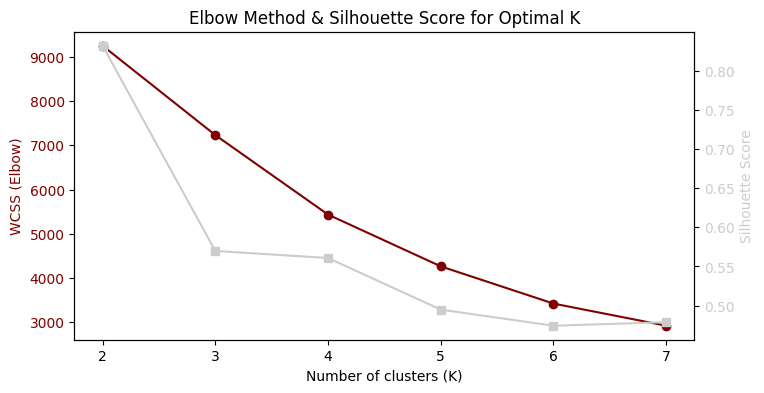

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

wcss = []
silhouette_scores = []
k_range = range(2, 8)

features_pca = df_agg_final[['PC1', 'PC2']]

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(features_pca)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(features_pca, labels))

fig, ax1 = plt.subplots(figsize=(8, 4))

color1 = '#800000'
ax1.set_xlabel('Number of clusters (K)')
ax1.set_ylabel('WCSS (Elbow)', color=color1)
ax1.plot(k_range, wcss, marker='o', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
color2 = '#cccccc'
ax2.set_ylabel('Silhouette Score', color=color2)
ax2.plot(k_range, silhouette_scores, marker='s', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Elbow Method & Silhouette Score for Optimal K')
plt.grid(False)
plt.show()

Pada tahap ini dilakukan eksperimen untuk menentukan jumlah cluster (K) yang paling optimal menggunakan dua pendekatan sekaligus, yaitu Elbow Method (WCSS) dan Silhouette Score. WCSS digunakan untuk melihat seberapa rapat data dalam cluster, sedangkan silhouette score mengukur seberapa baik pemisahan antar cluster.

Dari grafik yang dihasilkan, terlihat bahwa nilai WCSS terus menurun seiring bertambahnya jumlah cluster, yang memang wajar karena semakin banyak cluster, maka jarak antar data dalam cluster akan semakin kecil. Namun, penurunan yang cukup signifikan terjadi dari K=2 ke K=3, lalu mulai melandai setelah K=4. Ini menunjukkan bahwa titik siku (elbow) kemungkinan berada di sekitar K=3 atau K=4, karena setelah itu penurunannya tidak terlalu signifikan lagi.

Secara matematis murni, Silhouette Score menempatkan K=2 sebagai titik terbaik (0.83). Namun, keputusan sadar diambil untuk menggunakan K=3. Justifikasi utamanya adalah kebutuhan bisnis yang actionable. K=2 hanya membelah data menjadi 'Produk Anomali' dan 'Produk Normal' (terlalu general). Dengan K=3, kita berhasil memecah 'Data Normal' tersebut menjadi segmentasi yang jauh lebih strategis untuk tim marketing: Produk Premium, Produk Massal, dan Produk Kurang Laku.

In [ ]:
import numpy as np
for k, score in zip(k_range, silhouette_scores):
    print(f"K={k}, Silhouette={score:.4f}")

K=2, Silhouette=0.8320
K=3, Silhouette=0.5698
K=4, Silhouette=0.5608
K=5, Silhouette=0.4948
K=6, Silhouette=0.4743
K=7, Silhouette=0.4788


Pada bagian ini ditampilkan nilai silhouette score untuk setiap jumlah cluster dari K=2 sampai K=7. Terlihat bahwa nilai tertinggi ada di K=2 dengan skor 0.8320, yang artinya secara matematis, pemisahan antar cluster paling baik terjadi saat data dibagi menjadi dua kelompok. Namun, setelah K=2, nilai silhouette langsung turun cukup jauh di K=3 (0.5698) dan terus menurun di K berikutnya. Ini menunjukkan bahwa ketika jumlah cluster ditambah, batas antar cluster mulai tidak sejelas sebelumnya.

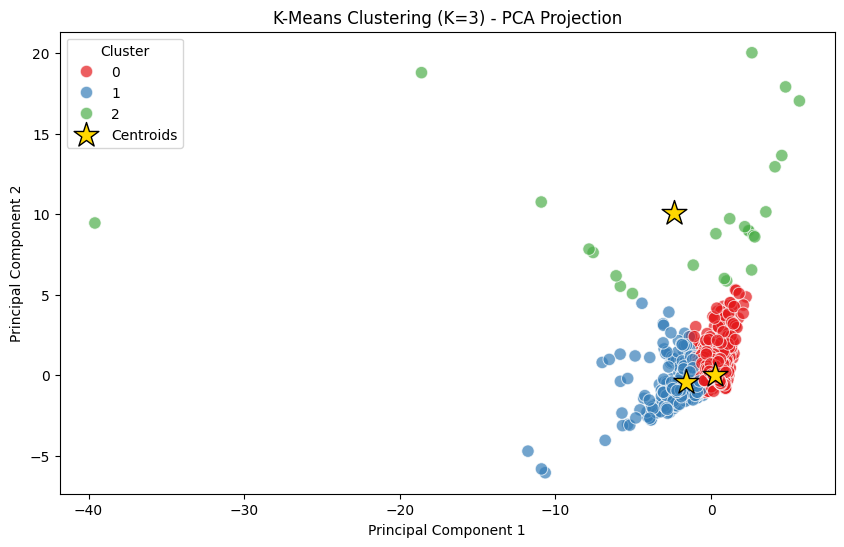

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
df_agg_final['cluster'] = kmeans_final.fit_predict(df_agg_final[['PC1', 'PC2']])

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x='PC1', y='PC2',
    hue='cluster',
    data=df_agg_final,
    palette='Set1',
    alpha=0.7,
    s=80
)

centroids = kmeans_final.cluster_centers_
plt.scatter(
    centroids[:, 0], centroids[:, 1],
    marker='*',
    s=350,
    color='#FFD700',
    edgecolors='black',
    linewidths=1,
    zorder=5,
    label='Centroids'
)

plt.title('K-Means Clustering (K=3) - PCA Projection')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()

Pada tahap ini, model K-Means akhirnya dilatih menggunakan K=3. Label cluster kemudian ditambahkan ke dataframe, sehingga setiap produk sekarang memiliki identitas kelompoknya masing-masing. Dari scatter plot yang dihasilkan berdasarkan PC1 dan PC2, terlihat bahwa data terbagi menjadi tiga kelompok dengan warna berbeda.

Jika dilihat dari persebarannya, cluster merah (0) dan biru (1) cenderung berdekatan dan cukup padat di area tengah, yang menandakan banyak produk memiliki karakteristik yang mirip satu sama lain. Sementara itu, cluster hijau (2) terlihat lebih menyebar dan berada lebih jauh dari pusat, bahkan ada beberapa titik yang cukup ekstrem. Ini menunjukkan bahwa cluster hijau kemungkinan berisi produk-produk dengan karakteristik yang berbeda signifikan. Titik centroid yang ditandai dengan bintang juga memperjelas posisi “pusat” dari masing-masing cluster. Jarak antar centroid yang cukup terlihat menandakan bahwa model berhasil membedakan kelompok produk meskipun masih ada sedikit overlap di area tertentu.

In [ ]:
profiling_cols = ['avg_price', 'total_sold', 'positive_pct', 'avg_review_len']
cluster_profile = df_agg_final.groupby('cluster')[profiling_cols].mean().round(2)
display(cluster_profile)

,avg_price,total_sold,positive_pct,avg_review_len
cluster,,,,
0,975492.52,707.99,1.00,66.05
1,191367.32,3875.38,0.88,102.28
2,39271069.68,40507.20,1.00,334.78


**Interpretasi 2 (Profiling Cluster):**

Cluster 0 memiliki rata-rata harga sekitar 975 ribu dengan jumlah penjualan yang relatif rendah (sekitar 707), tetapi memiliki persentase ulasan positif yang sangat tinggi (mendekati 100%) dan panjang ulasan yang cenderung pendek. Ini menunjukkan bahwa produk di cluster ini kemungkinan adalah produk dengan kualitas yang stabil dan jarang mendapatkan komplain, meskipun tidak terlalu laris. Secara bisnis, cluster ini bisa disebut sebagai **'Produk Stabil Kurang Laku'**, yaitu produk yang sebenarnya bagus tapi mungkin kurang optimal dari sisi pemasaran.

Cluster 1 memiliki rata-rata harga yang jauh lebih murah sekitar 191 ribu dengan jumlah penjualan paling tinggi di antara cluster lainnya (sekitar 3.875), namun persentase ulasan positifnya lebih rendah (sekitar 88%) dan panjang ulasannya lebih tinggi. Ini mengindikasikan bahwa produk di cluster ini cukup laris, tapi juga lebih banyak mendapatkan feedback, termasuk kemungkinan komplain. Bisa jadi karena ekspektasi pelanggan tidak selalu terpenuhi. Dari sisi bisnis, cluster ini cocok disebut **'Produk Murah Laris tapi Rentan Komplain'**, sehingga perlu perhatian lebih pada kualitas atau deskripsi produk.

Cluster 2 terlihat memiliki rata-rata harga yang sangat tinggi sekitar 39 juta dan jumlah penjualan yang juga sangat besar (sekitar 40.500). Selain itu, persentase ulasan positif tetap tinggi mencapai 100% dan memiliki panjang ulasan paling tinggi di antara semua cluster. Ini menunjukkan bahwa produk di cluster ini kemungkinan adalah produk premium atau high-end yang tetap diminati dan mendapatkan feedback yang sangat baik. Panjang ulasan yang tinggi juga bisa menandakan pengalaman pelanggan yang kuat, baik dalam bentuk apresiasi. Secara bisnis, cluster ini bisa disebut sebagai **'Produk Premium Berkinerja Tinggi'**, yang menjadi aset penting dan bisa dijadikan fokus utama dalam strategi bisnis.

In [ ]:
from sklearn.cluster import DBSCAN

print("--- Eksperimen Parameter DBSCAN ---")
for eps_val in [0.5, 0.8]:
    for min_s in [3, 5, 10]:
        test_dbscan = DBSCAN(eps=eps_val, min_samples=min_s)
        test_labels = test_dbscan.fit_predict(df_agg_final[['PC1', 'PC2']])
        anomali_count = list(test_labels).count(-1)
        print(f"eps={eps_val}, min_samples={min_s} -> Total Anomali: {anomali_count}")

--- Eksperimen Parameter DBSCAN ---
eps=0.5, min_samples=3 -> Total Anomali: 41
eps=0.5, min_samples=5 -> Total Anomali: 51
eps=0.5, min_samples=10 -> Total Anomali: 74
eps=0.8, min_samples=3 -> Total Anomali: 28
eps=0.8, min_samples=5 -> Total Anomali: 33
eps=0.8, min_samples=10 -> Total Anomali: 48


Pada bagian ini dilakukan percobaan beberapa kombinasi parameter eps dan min_samples untuk melihat bagaimana DBSCAN mengidentifikasi cluster dan anomali. eps digunakan untuk menentukan radius kedekatan antar titik, sementara min_samples digunakan untuk menentukan minimum jumlah titik untuk membentuk cluster. Dari hasil yang ditampilkan, terlihat bahwa semakin kecil nilai eps dan semakin besar min_samples, jumlah data yang dianggap sebagai anomali (-1) semakin banyak. Misalnya pada eps=0.5 dan min_samples=10, jumlah anomali mencapai 74, sedangkan pada eps=0.8 dan min_samples=3 hanya 28.

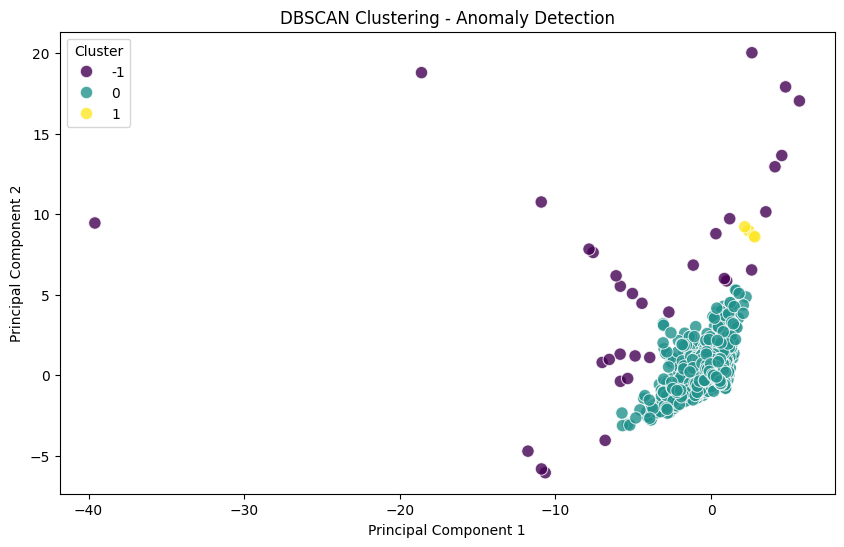

In [ ]:
dbscan = DBSCAN(eps=0.8, min_samples=5)
df_agg_final['dbscan_cluster'] = dbscan.fit_predict(df_agg_final[['PC1', 'PC2']])

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='PC1', y='PC2',
    hue='dbscan_cluster',
    data=df_agg_final,
    palette='viridis',
    alpha=0.8,
    s=80
)
plt.title('DBSCAN Clustering - Anomaly Detection')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()

Pada tahap ini, model DBSCAN dilatih menggunakan parameter eps=0.8 dan min_samples=5 dan hasilnya divisualisasikan dalam bentuk scatter plot berdasarkan PC1 dan PC2. Dari plot tersebut, terlihat bahwa sebagian besar data terkonsentrasi dalam satu cluster utama (warna dominan biru), sementara beberapa titik tersebar jauh dari pusat dan diberi label berbeda, termasuk label -1 sebagai anomali.

In [ ]:
anomalies = df_agg_final[df_agg_final['dbscan_cluster'] == -1]
print(f"Total Anomali Terdeteksi (Label -1): {len(anomalies)}")

Total Anomali Terdeteksi (Label -1): 33


**Interpretasi 3:** Perbedaan utama antara DBSCAN dan K-Means pada dataset ini terletak pada cara membentuk cluster. K-Means membagi seluruh data ke dalam sejumlah cluster yang sudah ditentukan sejak awal (misalnya K=3), sehingga semua produk pasti masuk ke salah satu kelompok. Sementara itu, DBSCAN tidak menentukan jumlah cluster di awal, tetapi membentuk cluster berdasarkan kepadatan data dan secara otomatis mendeteksi data yang tidak sesuai pola sebagai anomali. Pada kasus ini, DBSCAN terbukti berhasil menemukan produk-produk anomali yang sebelumnya tidak terlihat jelas pada K-Means. Hasilnya menunjukkan bahwa ada 33 produk yang terdeteksi dalam kategori anomali (label -1).

In [ ]:
from mlxtend.frequent_patterns import apriori, association_rules

transactions = df[['product_category', 'product_variant', 'sentiment_label']].copy()
transactions['product_variant'] = transactions['product_variant'].fillna('No Variant')
transactions_dummy = pd.get_dummies(transactions)

for ms in [0.05, 0.01]:
    freq = apriori(transactions_dummy, min_support=ms, use_colnames=True)
    print(f"Threshold {ms}: Menemukan {len(freq)} itemsets")

Threshold 0.05: Menemukan 24 itemsets
Threshold 0.01: Menemukan 33 itemsets


Pada bagian ini dilakukan percobaan untuk menentukan min_support dalam algoritma apriori. Hasilnya menunjukkan ketika menggunakan threshold 0.05 hanya ditemukan 24 kombinasi itemset, sedangkan saat diturunkan ke 0.01 jumlahnya meningkat menjadi 33 itemset. Ini menunjukkan bahwa semakin kecil nilai support, semakin banyak pola yang bisa ditemukan karena aturan yang jarang muncul pun ikut terdeteksi.

In [ ]:
from mlxtend.frequent_patterns import apriori, association_rules
import pandas as pd

df_neg = df[df['sentiment_label'] == 'negative']
df_pos = df[df['sentiment_label'] == 'positive'].sample(n=len(df_neg), random_state=42)
df_balanced = pd.concat([df_neg, df_pos])

transactions = df_balanced[['product_category', 'product_variant', 'sentiment_label']].copy()
transactions['product_variant'] = transactions['product_variant'].fillna('No Variant')
transactions_dummy = pd.get_dummies(transactions)

frequent_itemsets = apriori(transactions_dummy, min_support=0.01, use_colnames=True)
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)

rules_negative = rules[
    rules['consequents'].apply(lambda x: 'sentiment_label_negative' in x)
]

rules_negative = rules_negative.sort_values(by=['lift', 'confidence'], ascending=[False, False])
display(rules_negative[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

,antecedents,consequents,support,confidence,lift
45,(product_category_Makanan & Minuman),"(product_variant_No Variant, sentiment_label_negative)",0.136591,0.450413,1.723884
44,(product_variant_No Variant),"(sentiment_label_negative, product_category_Makanan & Minuman)",0.136591,0.243575,1.478123
54,(product_category_Pertukangan),"(product_variant_No Variant, sentiment_label_negative)",0.050125,0.320000,1.224748
14,(product_category_Olahraga),(sentiment_label_negative),0.173559,0.591880,1.183761
33,(product_variant_No Variant),"(product_category_Kesehatan, sentiment_label_negative)",0.015038,0.026816,1.097379
13,(product_category_Makanan & Minuman),(sentiment_label_negative),0.164787,0.543388,1.086777
42,"(product_variant_No Variant, product_category_Makanan & Minuman)",(sentiment_label_negative),0.136591,0.540943,1.081886
55,(product_variant_No Variant),"(product_category_Pertukangan, sentiment_label_negative)",0.050125,0.089385,1.072626
18,(product_category_Pertukangan),(sentiment_label_negative),0.083333,0.532000,1.064000


Selanjutnya, dilakukan penyeimbangan data (balancing) antara ulasan negatif dan positif dengan cara mengambil jumlah data positif yang sama dengan negatif. Ini penting karena data sangat didominasi oleh ulasan positif, sehingga tanpa balancing, aturan yang muncul hampir pasti bias ke sentimen positif saja. Setelah itu, data diubah menjadi format dummy agar bisa diproses oleh algoritma apriori dengan min_support=0.01. Kemudian dihasilkan frequent itemsets dan dilanjutkan dengan pembentukan association rules menggunakan metrik lift.

Disini, kami berfokus pada aturan dengan konsekuen sentiment_label_negative untuk mengetahui kombinasi kategori dan varian produk apa yang paling sering berasosiasi dengan ulasan negatif. Hasilnya terlihat bahwa beberapa pola cukup menonjol. Salah satu aturan paling kuat adalah kombinasi kategori “Makanan & Minuman” dengan produk tanpa varian (No Variant) yang memiliki confidence sekitar 45% dan lift sebesar 1.72. Ini berarti, ketika produk berada di kategori tersebut tanpa varian, kemungkinan munculnya ulasan negatif cukup tinggi dibandingkan rata-rata. Selain itu, kategori Olahraga juga menunjukkan kecenderungan tinggi terhadap ulasan negatif dengan confidence hampir 59%. Kategori Pertukangan juga muncul beberapa kali, meskipun dengan kekuatan asosiasi yang sedikit lebih rendah.



**Interpretasi 4:** Penggabungan analisis Clustering dan Association Rules menghasilkan beberapa strategi prioritas, di mana intervensi pada kategori Makanan & Minuman menjadi fokus utama. Data menunjukkan adanya blind spot pada produk tanpa varian (No Variant) di kategori ini yang memiliki korelasi kuat terhadap sentimen negatif dengan nilai Lift sebesar 1,72 dan tingkat Confidence 45%. Sebagai langkah preventif, perusahaan perlu mewajibkan para seller untuk mencantumkan detail varian yang spesifik seperti rasa atau ukuran guna menyelaraskan ekspektasi pembeli.

Implementasi kebijakan ini diprediksi dapat menekan tingkat komplain pelanggan akibat ketidaksesuaian barang hingga 40-45% pada kategori tersebut.Selain itu, pembenahan kualitas perlu diprioritaskan pada kategori Olahraga yang mencatatkan tingkat Confidence hingga 59,1% terhadap ulasan negatif. Langkah ini krusial untuk memperbaiki citra produk di Cluster 1 yang selama ini dikenal sebagai kelompok produk murah dan laris namun sangat rentan terhadap komplain. Edukasi melalui push-notification mengenai standar pengemasan dan quality control kepada para penjual di kategori ini diharapkan mampu mengurangi dominasi sentimen negatif secara signifikan.

Secara strategis, optimalisasi jangka panjang harus difokuskan pada penguatan Cluster 0 dan investigasi Cluster 2. Produk di Cluster 0 yang merupakan kelompok produk stabil dengan nol komplain perlu mendapatkan exposure lebih tinggi melalui algoritma pencarian karena potensinya dalam meningkatkan Conversion Rate tanpa risiko retur. Di sisi lain, temuan 33 entitas produk anomali ekstrem (Label -1) oleh DBSCAN memerlukan audit mendalam oleh tim Risk Management. Investigasi ini bertujuan untuk memastikan apakah data tersebut merupakan transaksi grosir yang valid atau justru indikasi manipulasi ulasan (Fake Orders) yang dapat merusak integritas ekosistem platform
